# 16 特征效率分析示例

本示例展示 `hscredit.report.feature_efficiency_analysis` 的典型用法：

- 手工分箱 vs 自动分箱的分箱表对比
- 一行四列的组合图：手工分箱图、自动分箱图、KS 曲线、ROC 曲线
- 传入日期字段或分组字段时，输出手工/自动两张 `bin_trend_plot` 趋势图
- 同时演示 `target` 模式和 `overdue` 模式

In [1]:
import os, sys
sys.path.append('../')

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from hscredit import init_setting
from hscredit.report import feature_efficiency_analysis
from hscredit.utils import germancredit

# plt.rcParams['figure.dpi'] = 120
init_setting()

In [3]:
df = germancredit().copy()
df['target'] = df['class'].astype(int)
df['apply_date'] = pd.date_range('2023-01-01', periods=len(df), freq='D')
df['MOB1'] = np.where(df['class'].astype(int).eq(1), 4 + (np.arange(len(df)) % 5), np.arange(len(df)) % 3)

print(f'样本量: {len(df):,}')
print(f'坏样本率: {df["target"].mean():.2%}')
print(f'日期范围: {df["apply_date"].min().date()} ~ {df["apply_date"].max().date()}')
display(df[['credit_amount', 'duration_in_month', 'housing', 'class', 'target', 'apply_date', 'MOB1']].head())

样本量: 1,000
坏样本率: 30.00%
日期范围: 2023-01-01 ~ 2025-09-26


,credit_amount,duration_in_month,housing,class,target,apply_date,MOB1
0,1169,6,own,0,0,2023-01-01,0
1,5951,48,own,1,1,2023-01-02,5
2,2096,12,own,0,0,2023-01-03,2
3,7882,42,for free,0,0,2023-01-04,0
4,4870,24,for free,1,1,2023-01-05,8


## 1. target 模式: 手工分箱 vs 自动分箱

这里以 `credit_amount` 为例，手工给定分箱边界，同时使用 `mdlp` 做自动分箱。
为了展示趋势图，还额外传入了日期字段 `apply_date` 和分组字段 `housing`。

自动分箱规则: [3972.25, 5969.95, 9162.7]


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,credit_amount,credit_amount,"[-inf, 1000)",116,79,37,0.1160,0.1129,0.1233,0.3190,...,0.1070,1.0632,0.0083,0.0715,1.0632,0.0083,0.0715,79,37,0.0105
1,credit_amount,credit_amount,"[1000, 2500)",421,311,110,0.4210,0.4443,0.3667,0.2613,...,0.1070,0.8709,-0.0938,-0.2229,0.9125,-0.1015,-0.1890,390,147,0.0671
2,credit_amount,credit_amount,"[2500, 5000)",275,200,75,0.2750,0.2857,0.2500,0.2727,...,0.1070,0.9091,-0.0345,-0.1254,0.9113,-0.3830,-0.4716,590,222,0.1029
3,credit_amount,credit_amount,"[5000, 8000)",118,78,40,0.1180,0.1114,0.1333,0.3390,...,0.1070,1.1299,0.0174,0.1473,0.9391,-0.8095,-0.8705,668,262,0.0810
4,credit_amount,credit_amount,"[8000, +inf)",70,32,38,0.0700,0.0457,0.1267,0.5429,...,0.1070,1.8095,0.0609,0.8705,1.0000,1.0000,1.0000,700,300,0.0000


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,credit_amount,credit_amount,"[-inf, 3972.25)",750,555,195,0.7500,0.7929,0.6500,0.2600,...,0.1352,0.8667,-0.4000,-0.5333,0.8667,-0.4000,-0.5333,555,195,0.1429
1,credit_amount,credit_amount,"[3972.25, 5969.95)",100,64,36,0.1000,0.0914,0.1200,0.3600,...,0.1352,1.2000,0.0222,0.2222,0.9059,-0.5333,-0.6275,619,231,0.1143
2,credit_amount,credit_amount,"[5969.95, 9162.7)",100,60,40,0.1000,0.0857,0.1333,0.4000,...,0.1352,1.3333,0.0370,0.3704,0.9509,-0.9333,-0.9825,679,271,0.0667
3,credit_amount,credit_amount,"[9162.7, +inf)",50,21,29,0.0500,0.0300,0.0967,0.5800,...,0.1352,1.9333,0.0491,0.9825,1.0000,1.0000,1.0000,700,300,0.0000


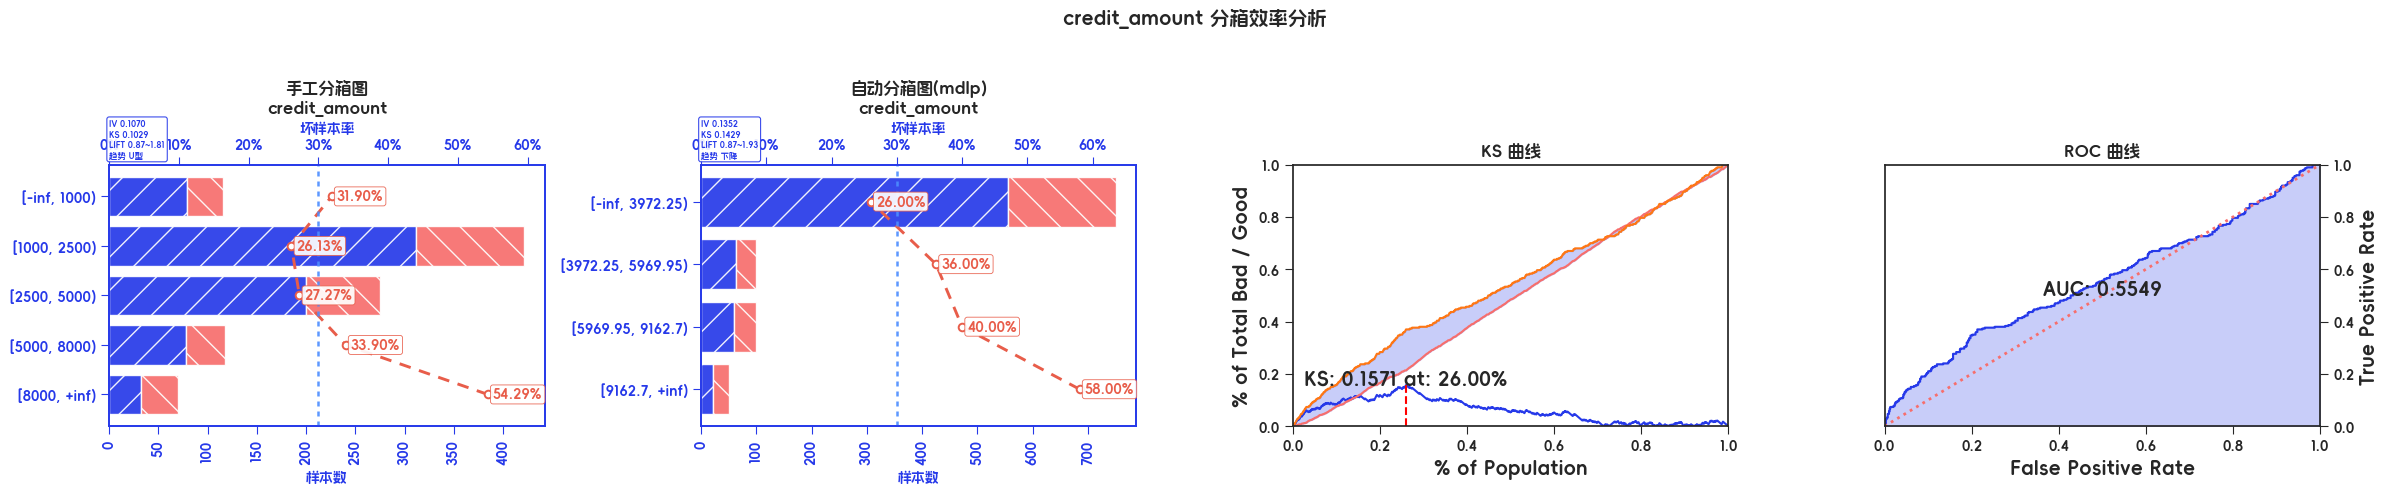

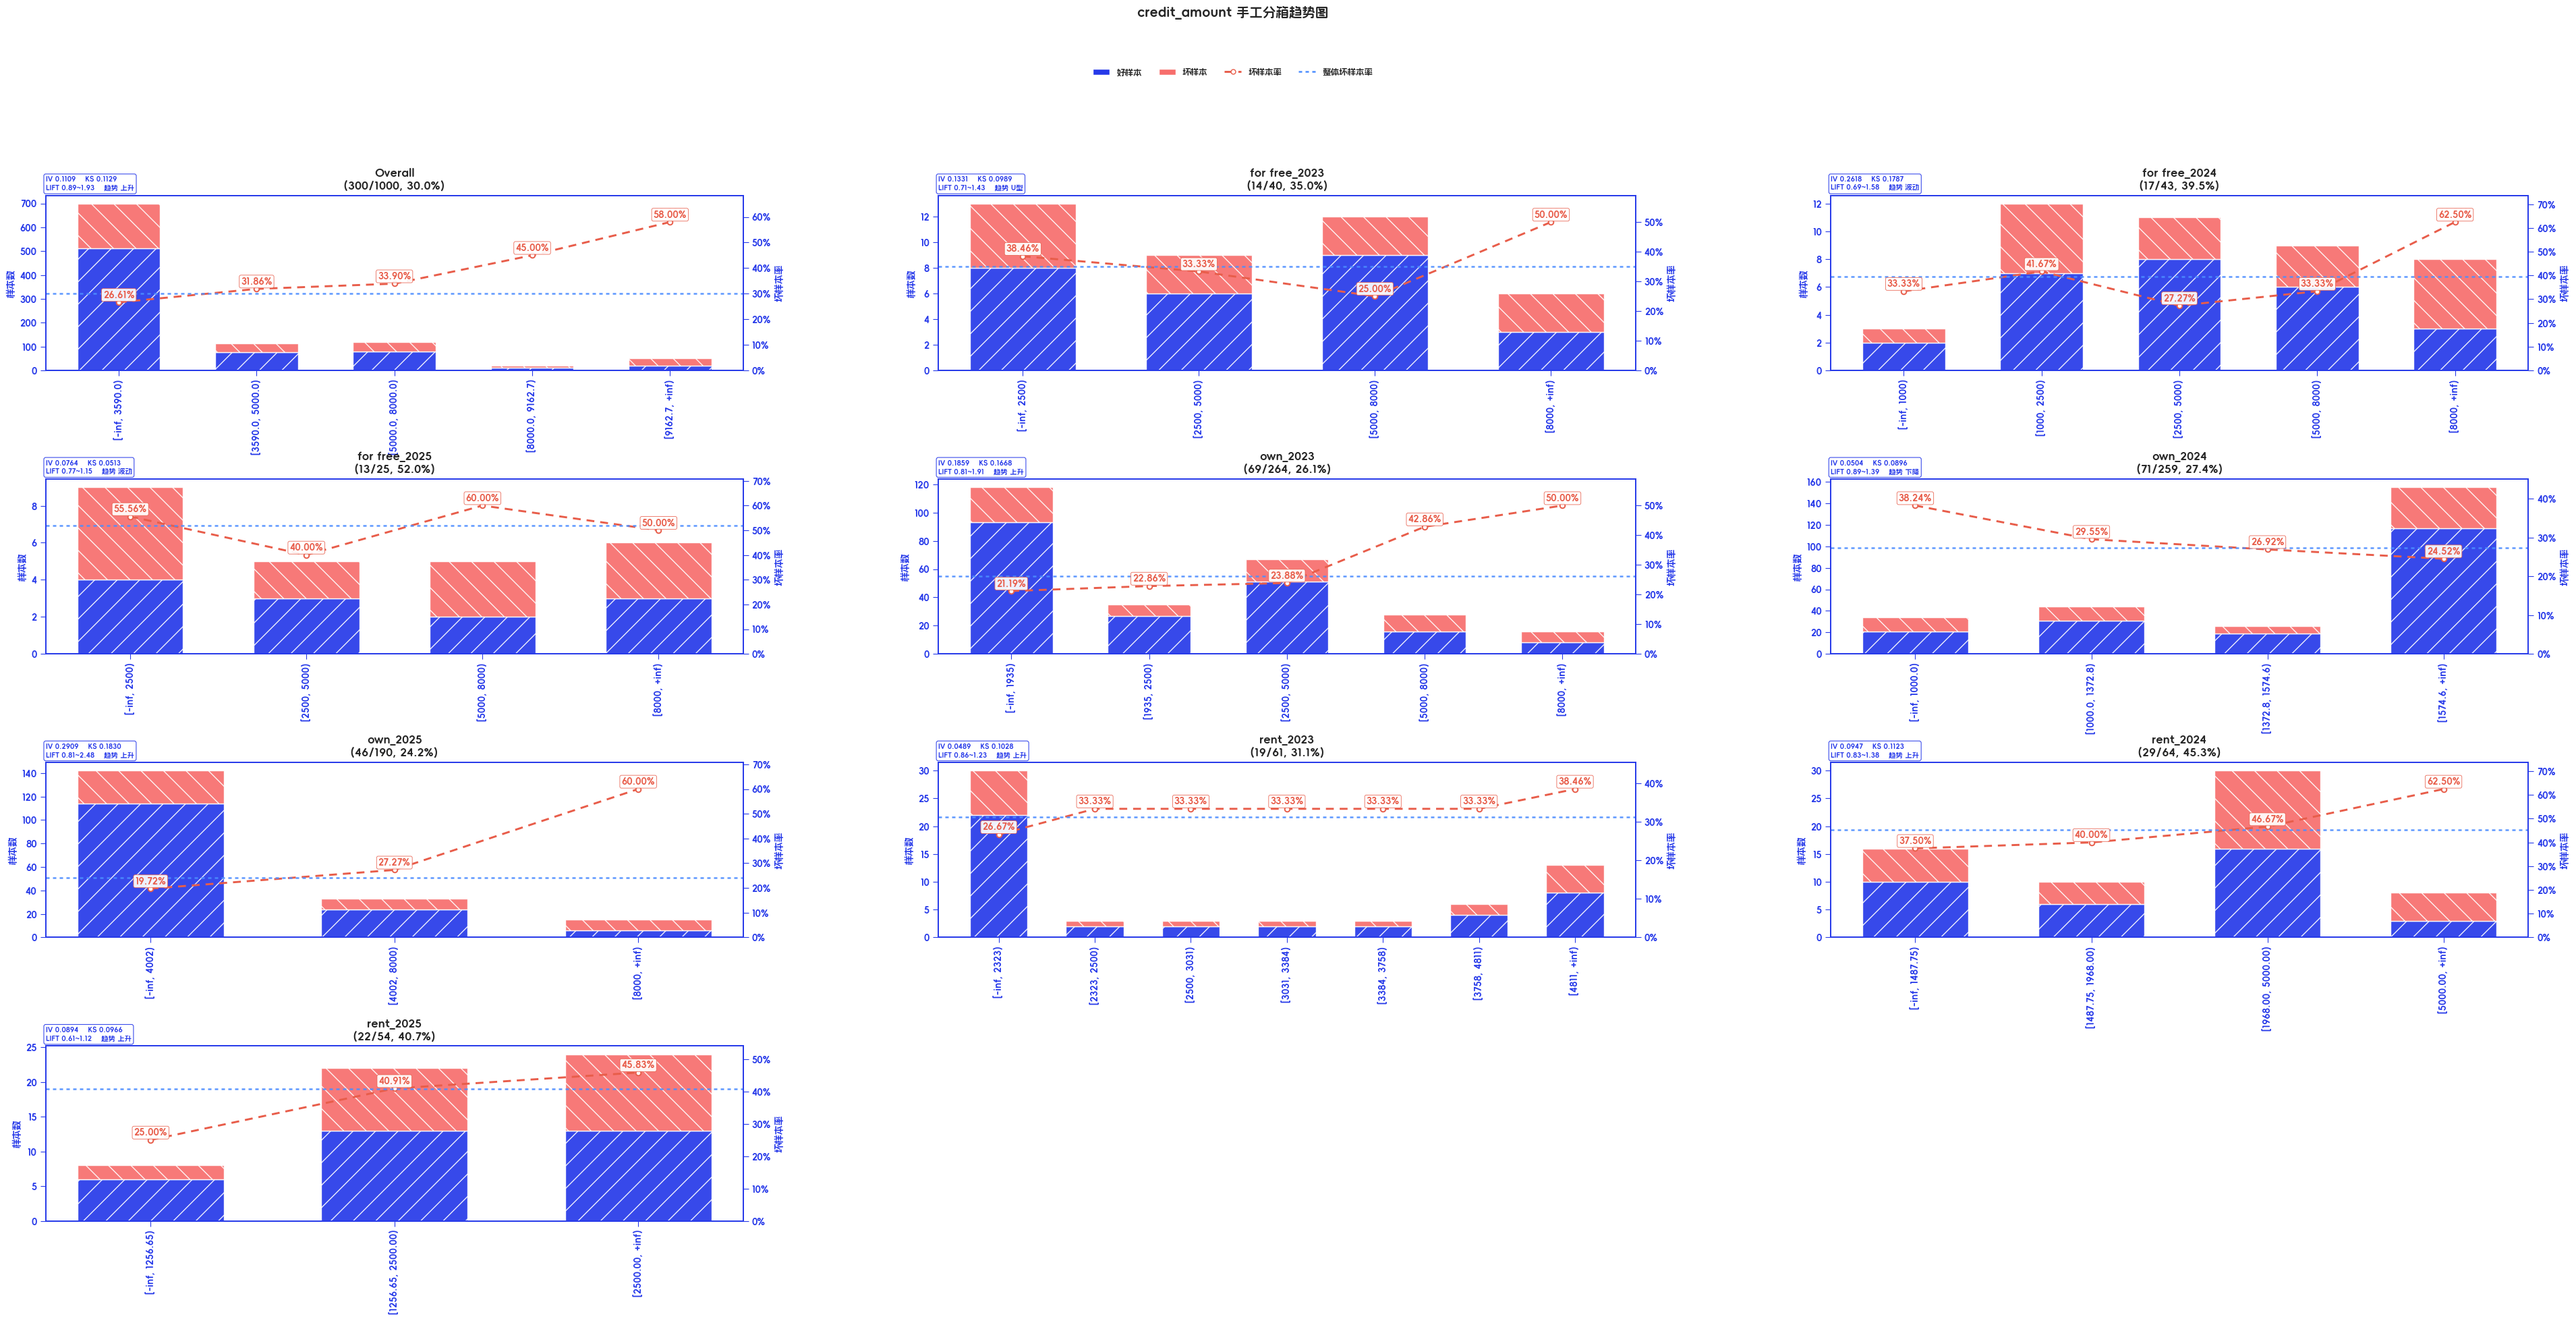

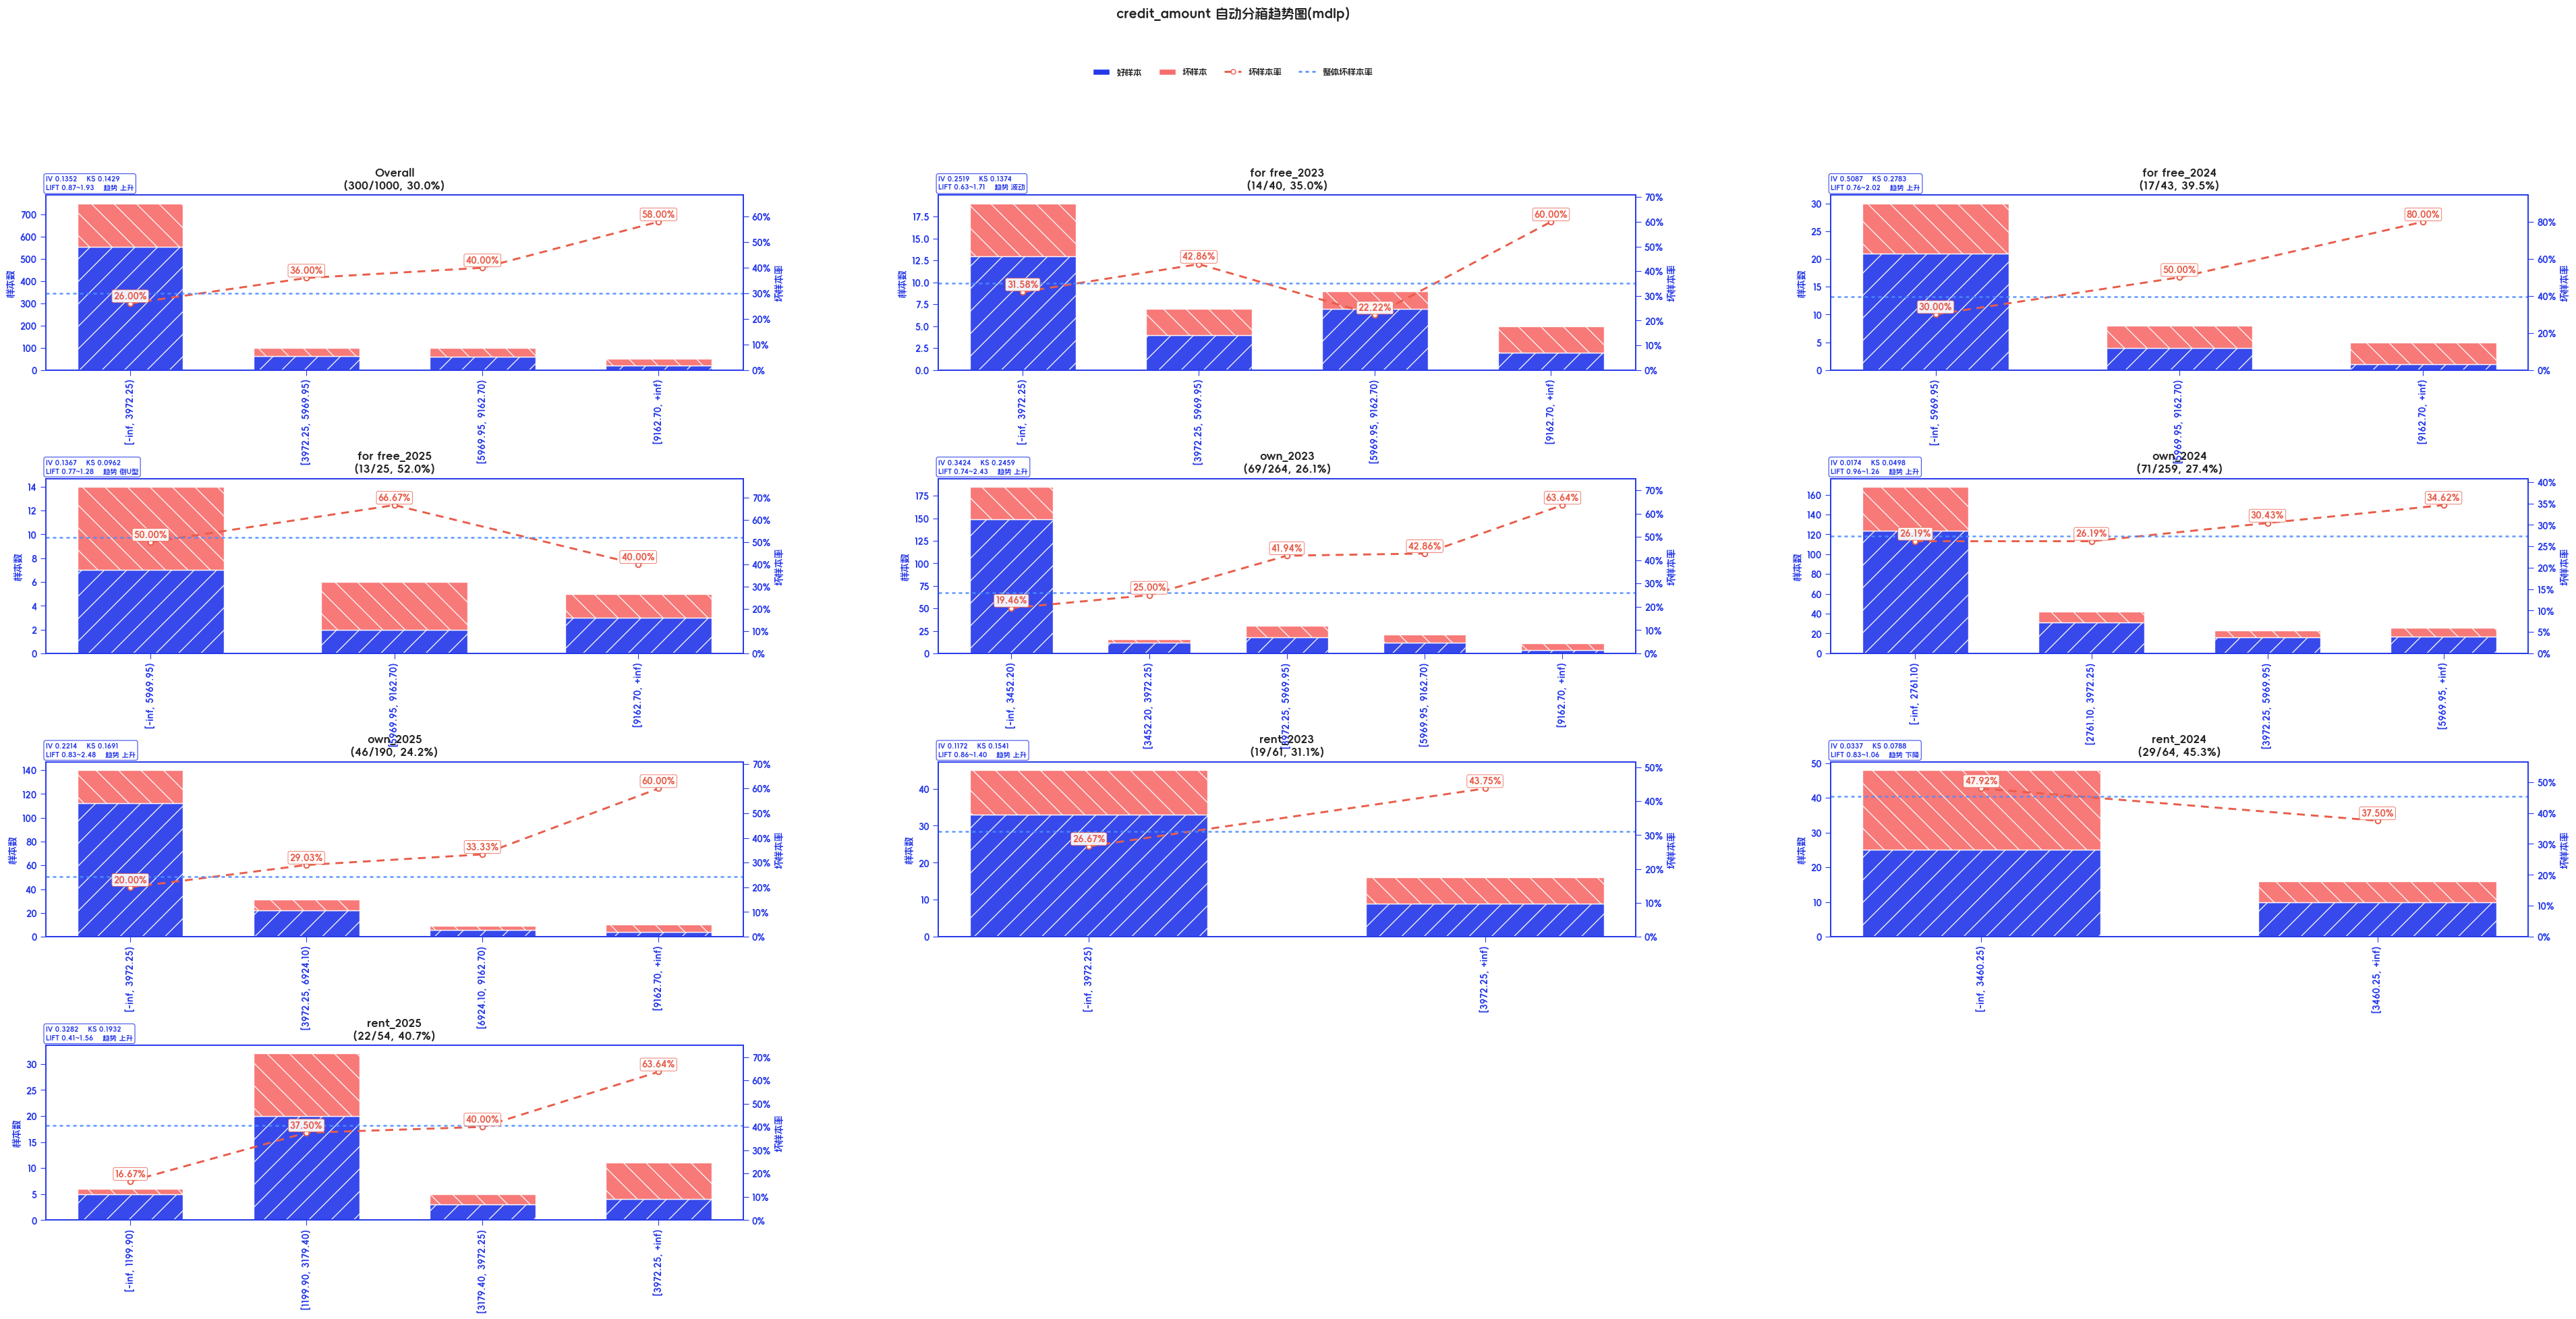

In [4]:
target_result = feature_efficiency_analysis(
    data=df,
    feature='credit_amount',
    manual_rules=[1000, 2500, 5000, 8000],
    target='target',
    auto_method='mdlp',
    date_col='apply_date',
    group_cols='housing',
    desc='credit_amount',
    trend_figsize=(40, 20),
    date_freq='Y',
);

print('自动分箱规则:', target_result['auto_rules'])
display(target_result['manual_table'])
display(target_result['auto_table'])

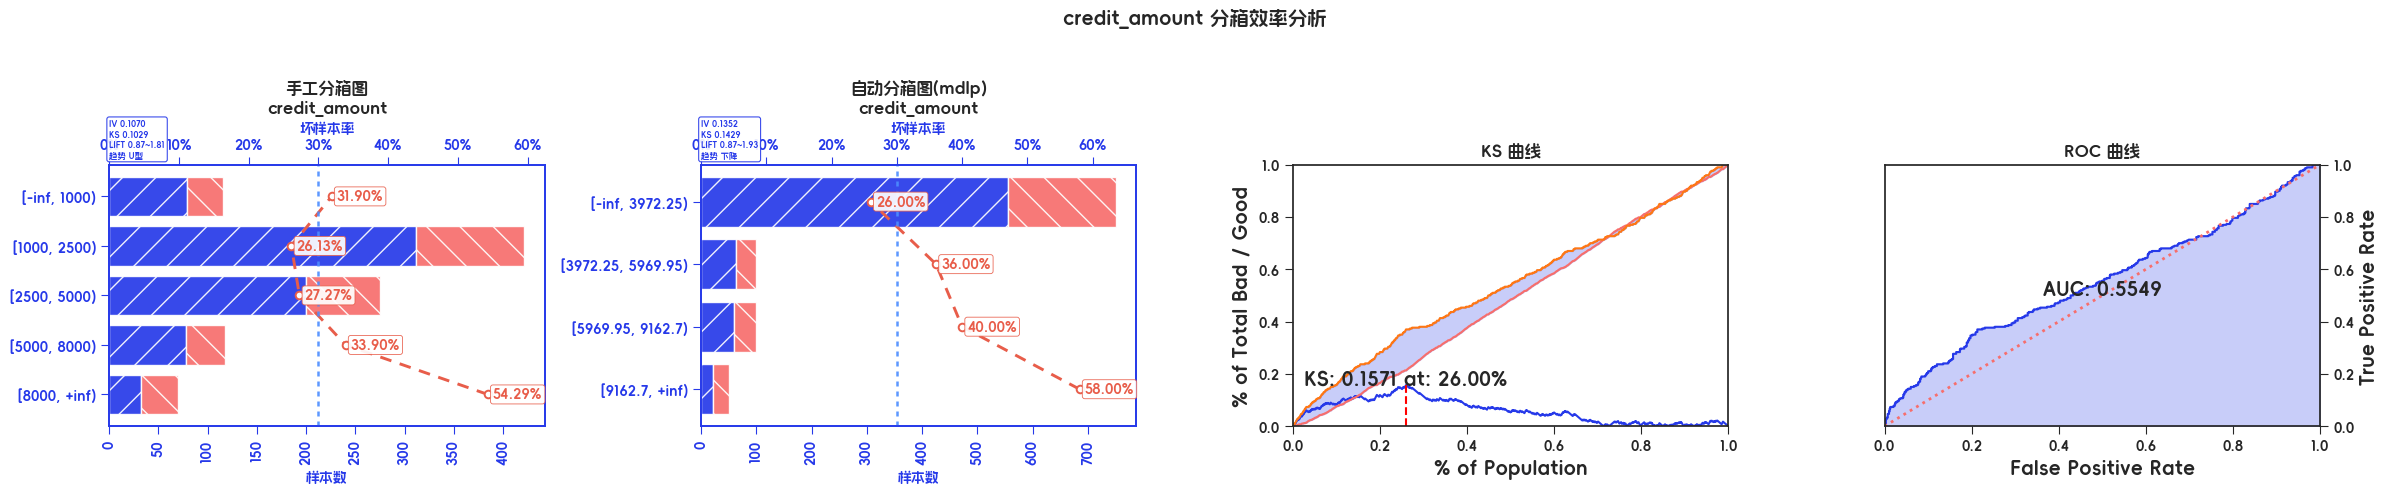

In [5]:
target_result['comparison_figure']

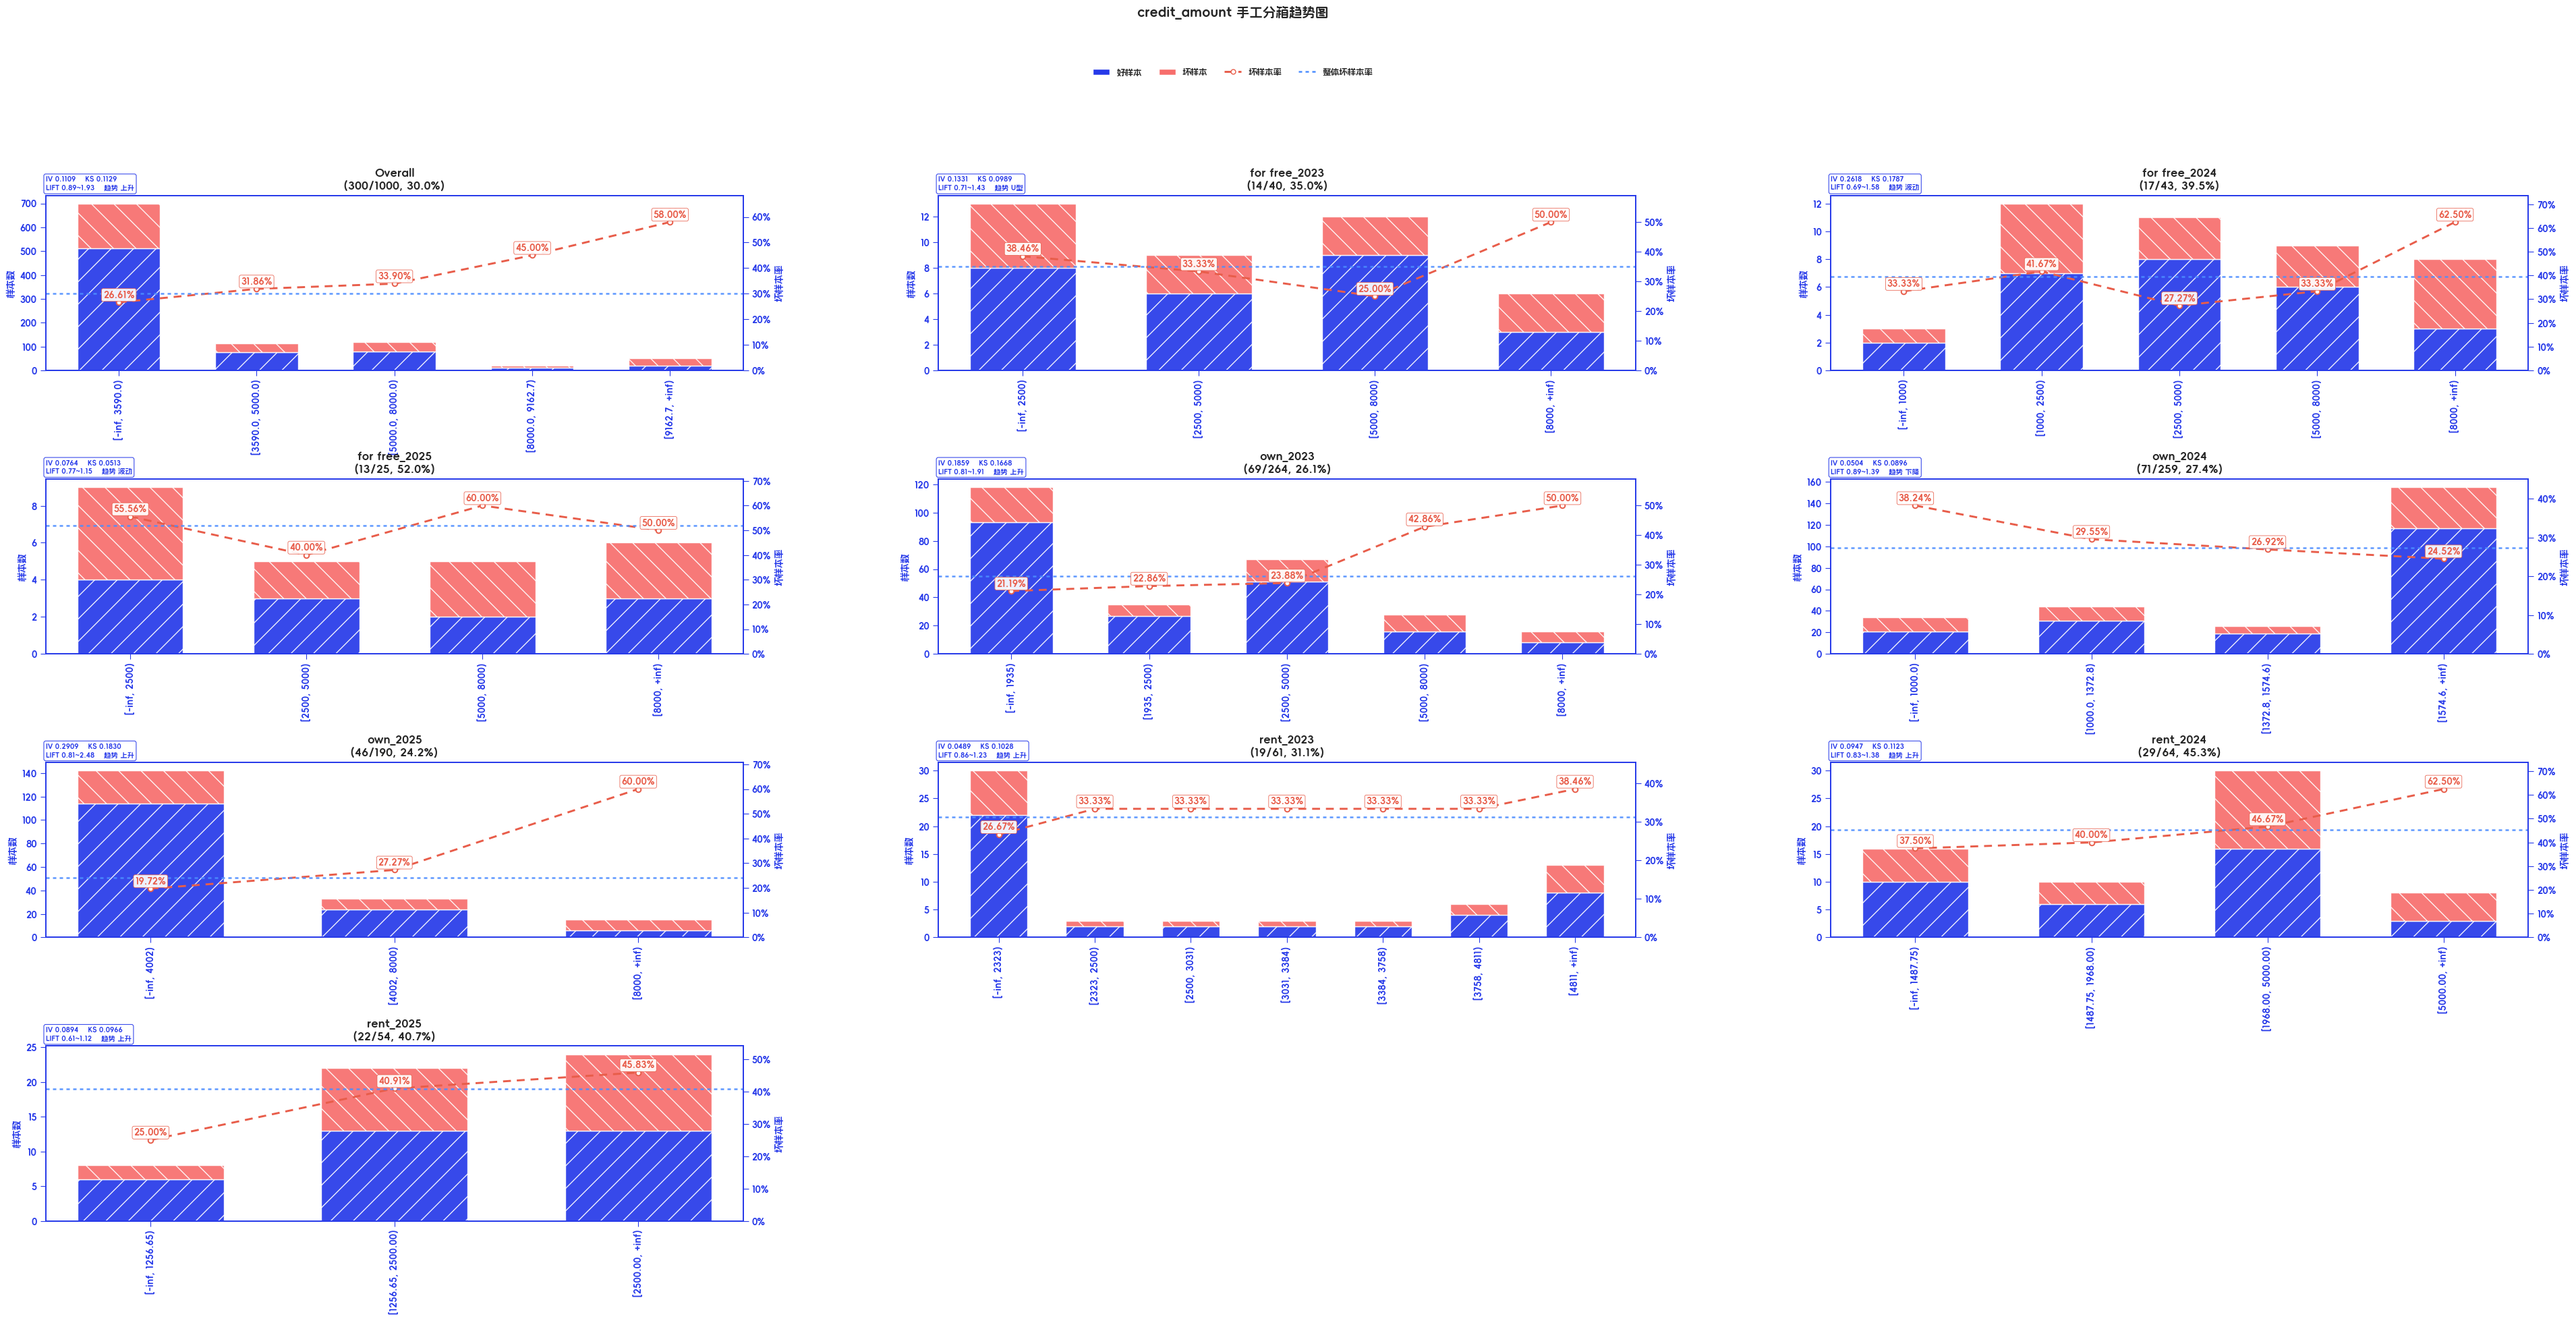

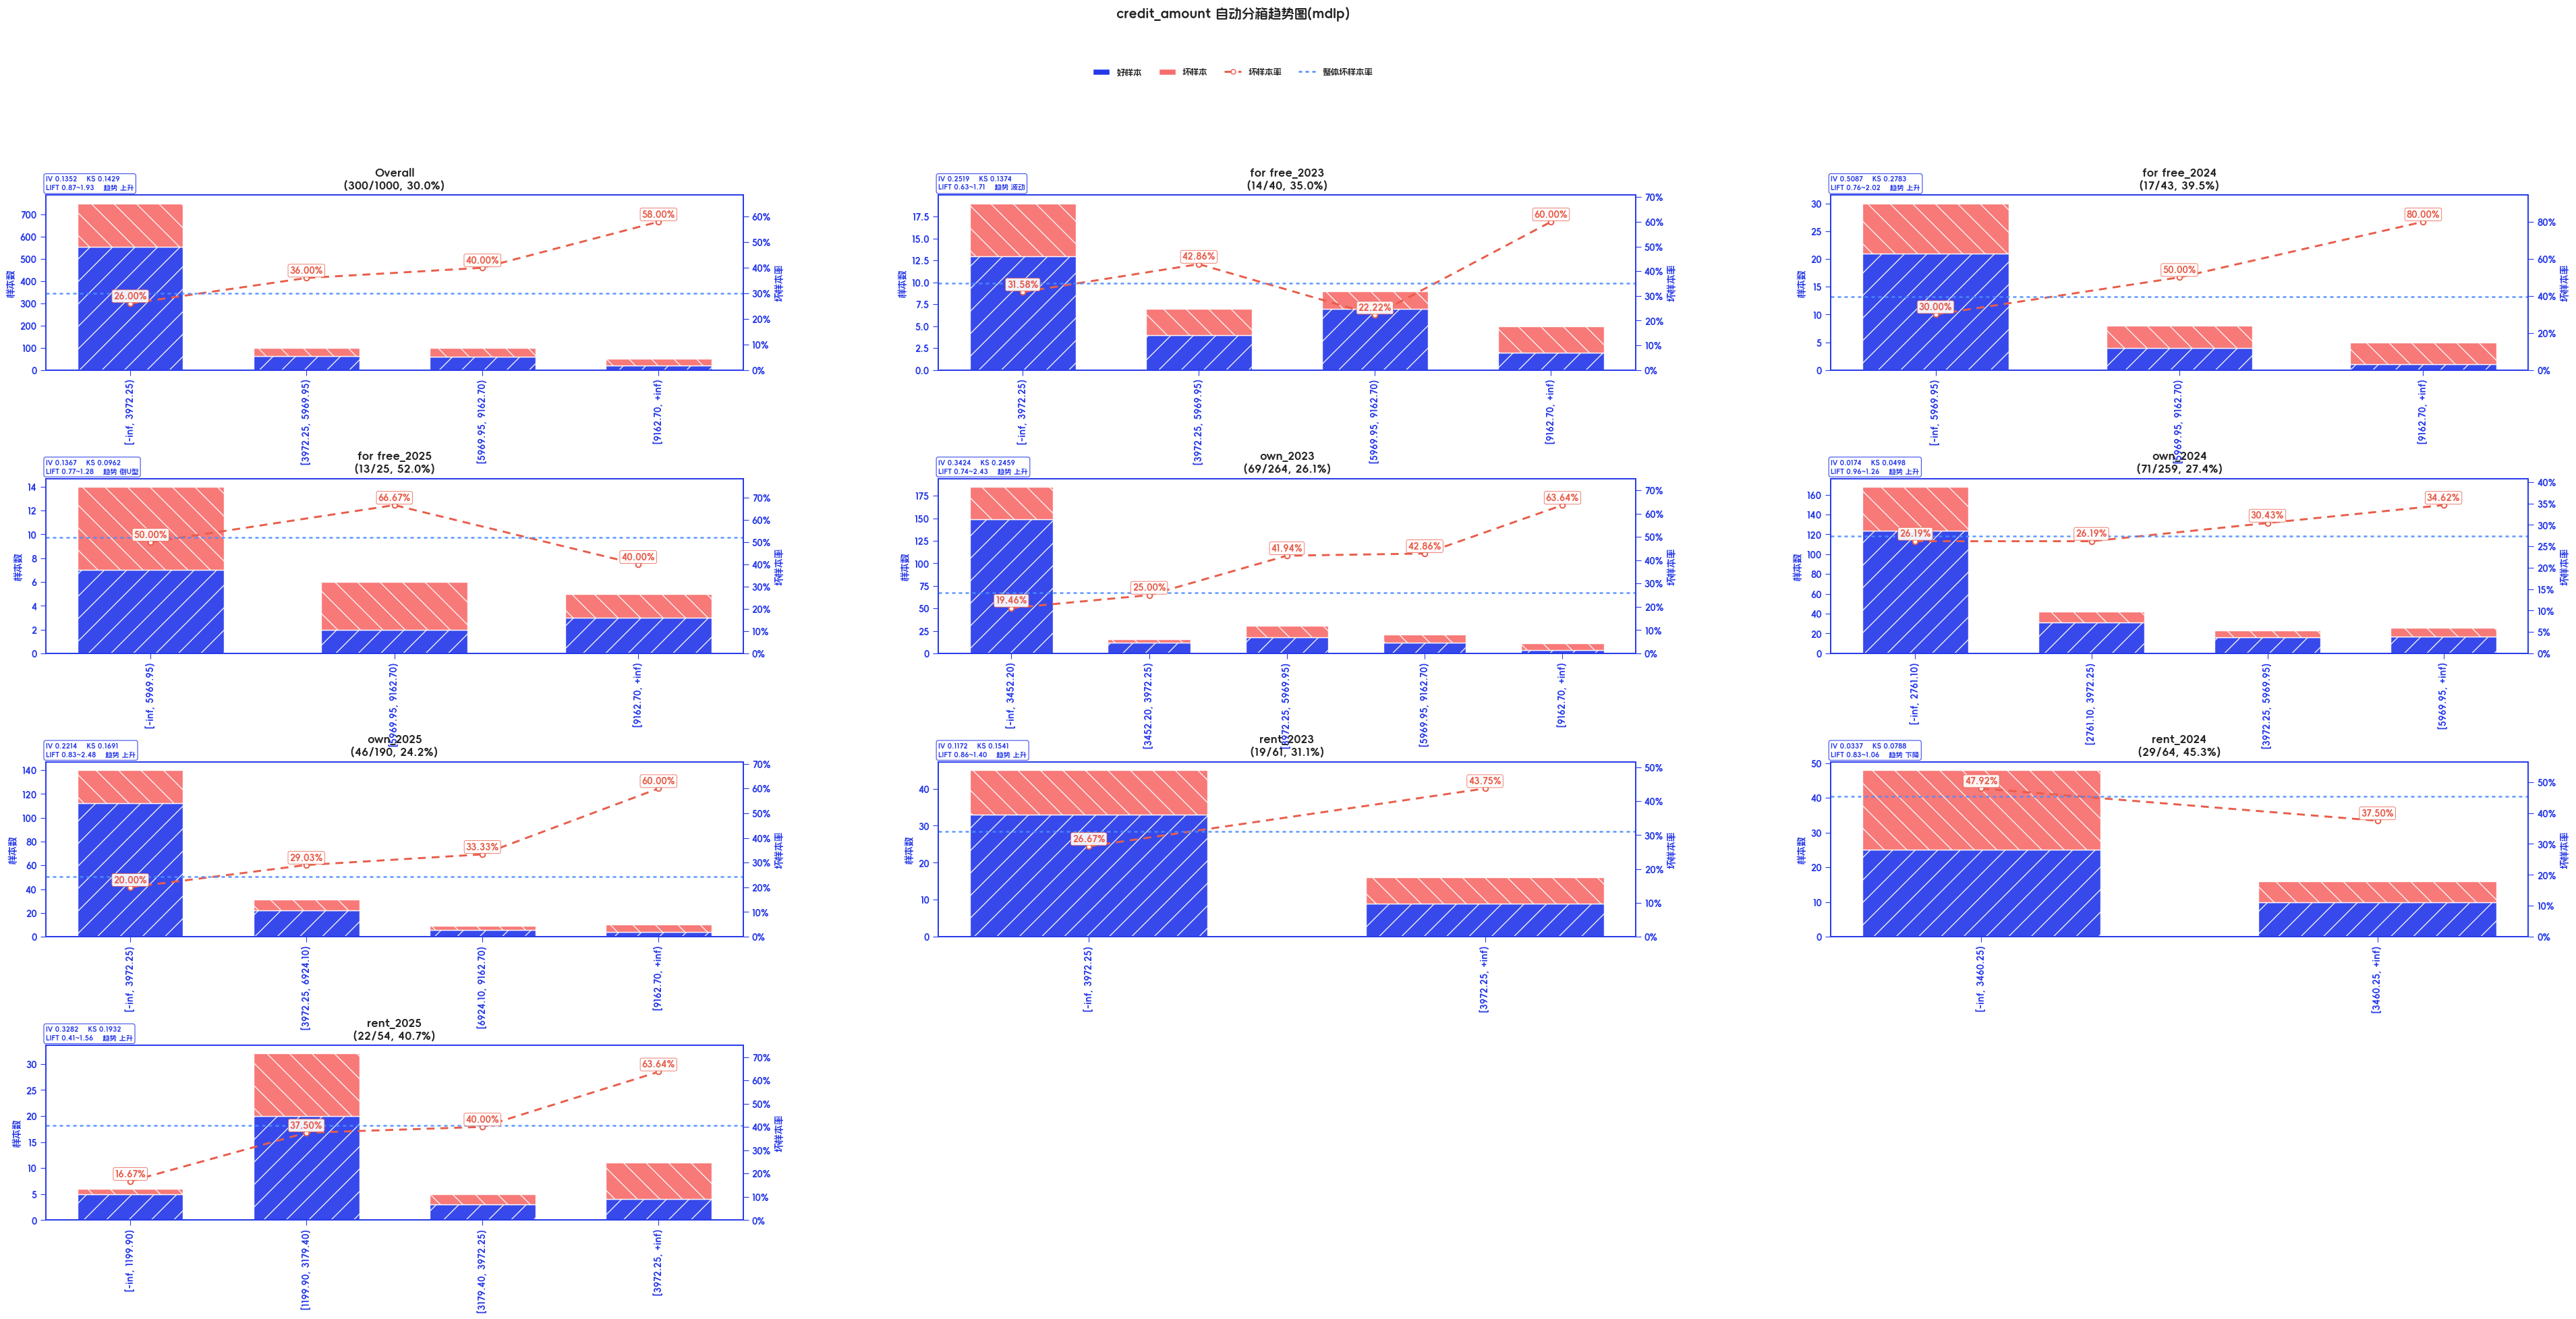

In [6]:
display(target_result['trend_figures']['manual'])
display(target_result['trend_figures']['auto'])

## 2. overdue 模式: 自动构造目标列

当传入 `overdue` 和 `dpd` 时，方法会自动生成类似 `MOB1 3+` 的二分类目标列。
这里使用 `duration_in_month` 演示该模式，并按 `housing` 输出趋势图。

实际目标列: MOB1 3+
自动分箱规则: [9.0, 18.0, 36.0, 48.0]


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,duration_in_month,duration_in_month,"[-inf, 12)",359,283,76,0.3590,0.4043,0.2533,0.2117,...,0.1824,0.7057,-0.1648,-0.4592,0.7057,-0.1648,-0.4592,283,76,0.1510
1,duration_in_month,duration_in_month,"[12, 24)",411,289,122,0.4110,0.4129,0.4067,0.2968,...,0.1824,0.9895,-0.0074,-0.0179,0.8571,-0.4783,-0.6211,572,198,0.1571
2,duration_in_month,duration_in_month,"[24, 36)",143,86,57,0.1430,0.1229,0.1900,0.3986,...,0.1824,1.3287,0.0548,0.3835,0.9310,-0.7241,-0.7931,658,255,0.0900
3,duration_in_month,duration_in_month,"[36, +inf)",87,42,45,0.0870,0.0600,0.1500,0.5172,...,0.1824,1.7241,0.0690,0.7931,1.0000,1.0000,1.0000,700,300,0.0000


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,...,指标IV值,LIFT值,坏账改善,风险拒绝比,累积LIFT值,累积坏账改善,累计风险拒绝比,累积好样本数,累积坏样本数,分档KS值
0,duration_in_month,duration_in_month,"[-inf, 9.0)",143,119,24,0.1430,0.1700,0.0800,0.1678,...,0.1701,0.5594,-0.0735,-0.5141,0.5594,-0.0735,-0.5141,119,24,0.0900
1,duration_in_month,duration_in_month,"[9.0, 18.0)",403,295,108,0.4030,0.4214,0.3600,0.2680,...,0.1701,0.8933,-0.0720,-0.1787,0.8059,-0.2335,-0.4276,414,132,0.1514
2,duration_in_month,duration_in_month,"[18.0, 36.0)",367,244,123,0.3670,0.3486,0.4100,0.3352,...,0.1701,1.1172,0.0679,0.1851,0.9310,-0.7241,-0.7931,658,255,0.0900
3,duration_in_month,duration_in_month,"[36.0, 48.0)",71,34,37,0.0710,0.0486,0.1233,0.5211,...,0.1701,1.7371,0.0563,0.7934,0.9892,-0.6667,-0.6775,692,292,0.0152
4,duration_in_month,duration_in_month,"[48.0, +inf)",16,8,8,0.0160,0.0114,0.0267,0.5000,...,0.1701,1.6667,0.0108,0.6775,1.0000,1.0000,1.0000,700,300,0.0000


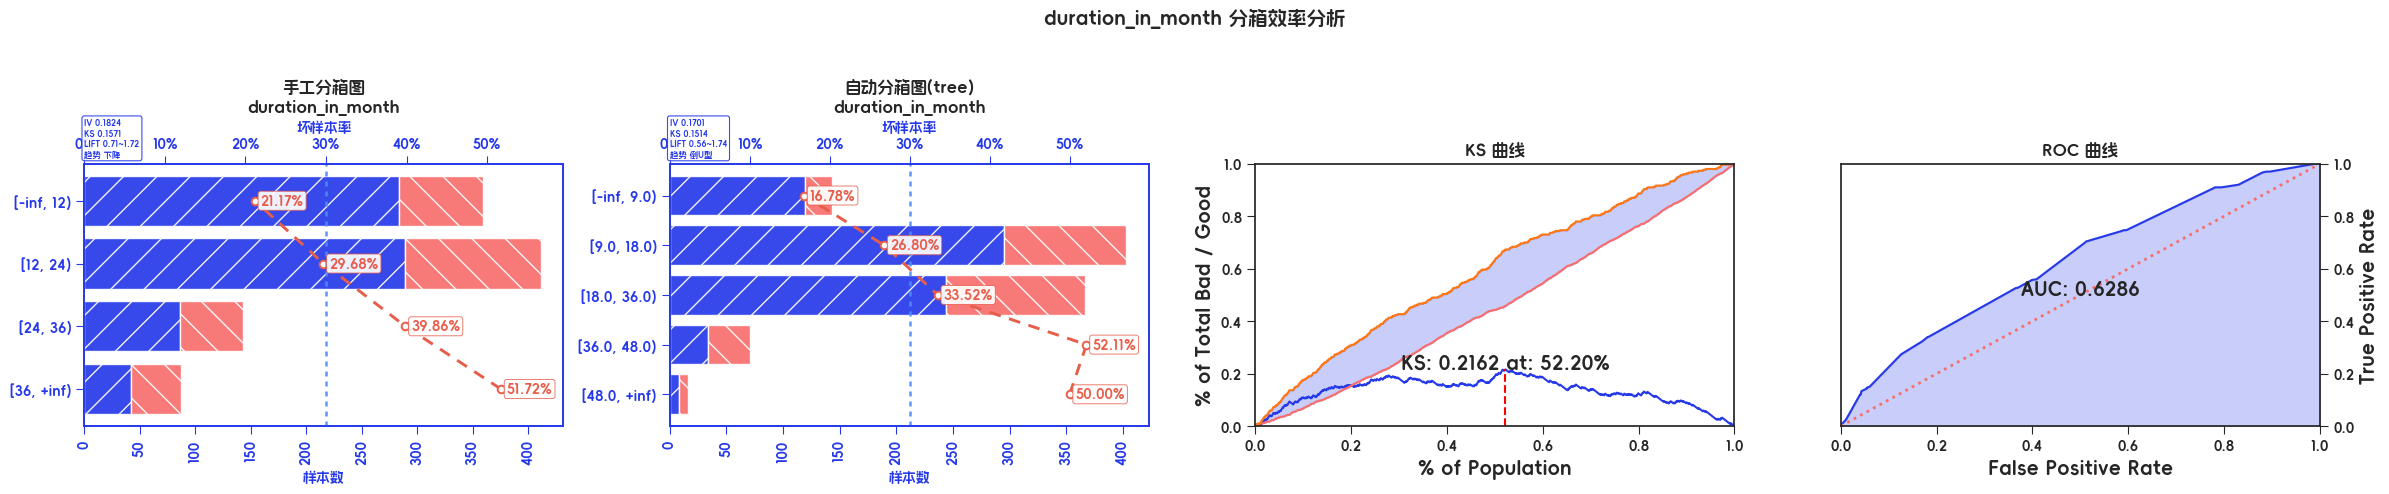

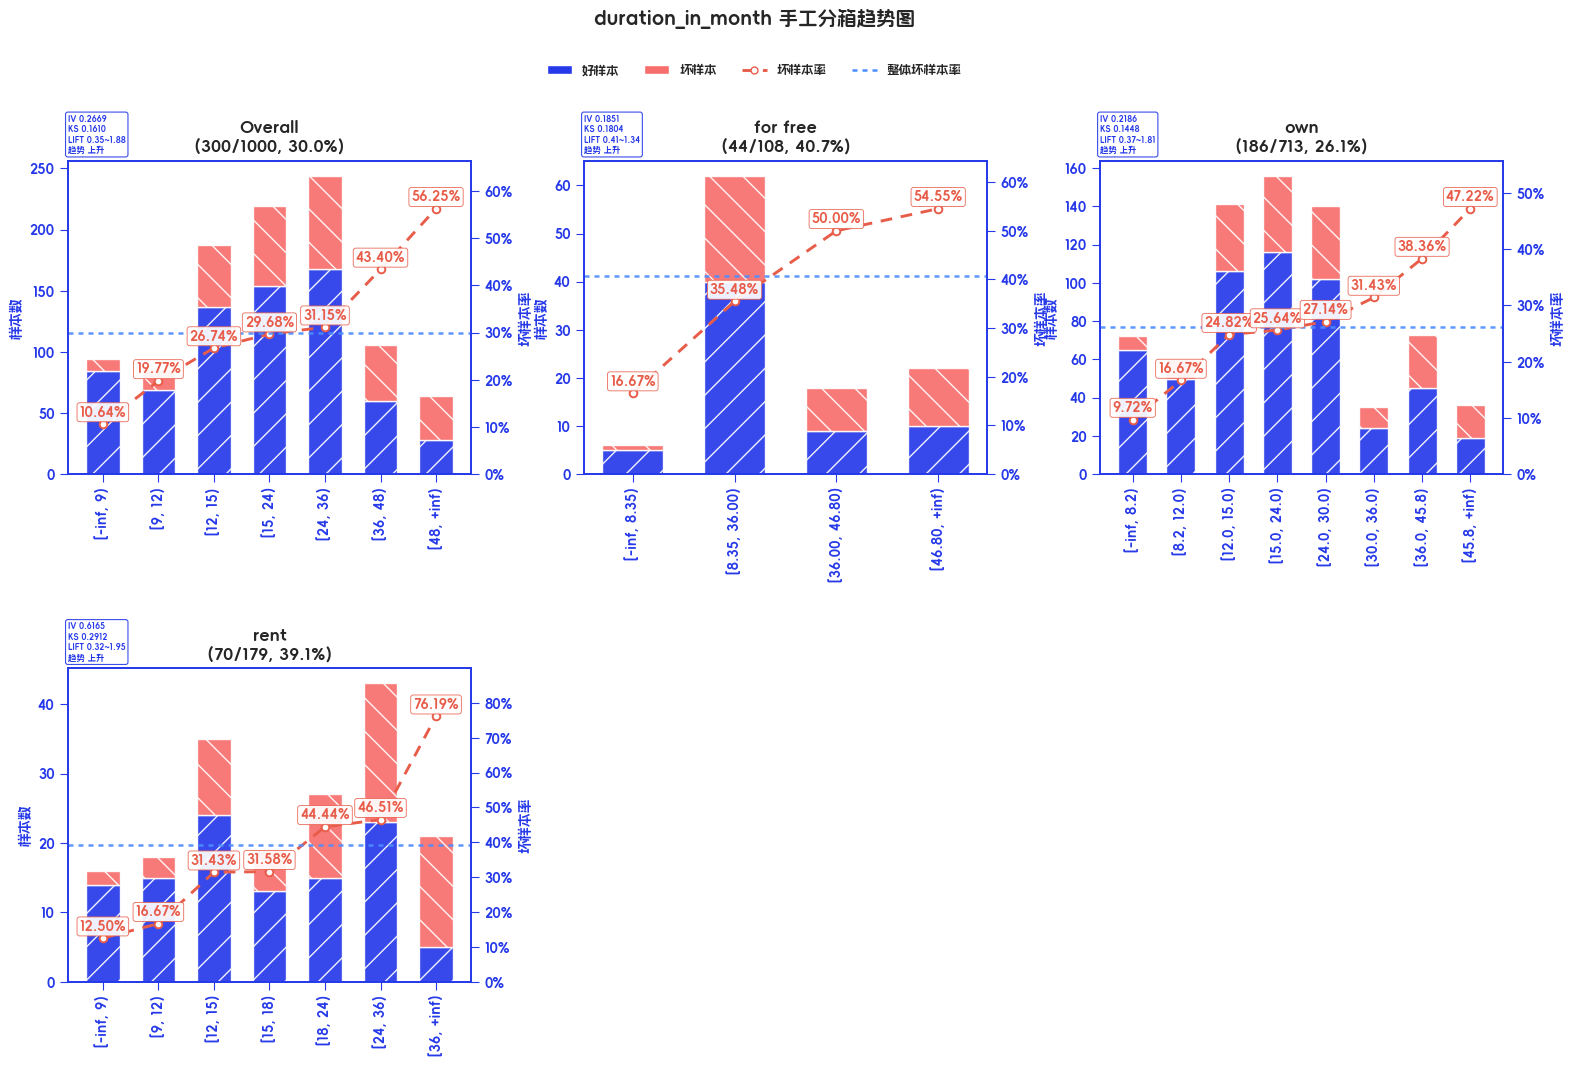

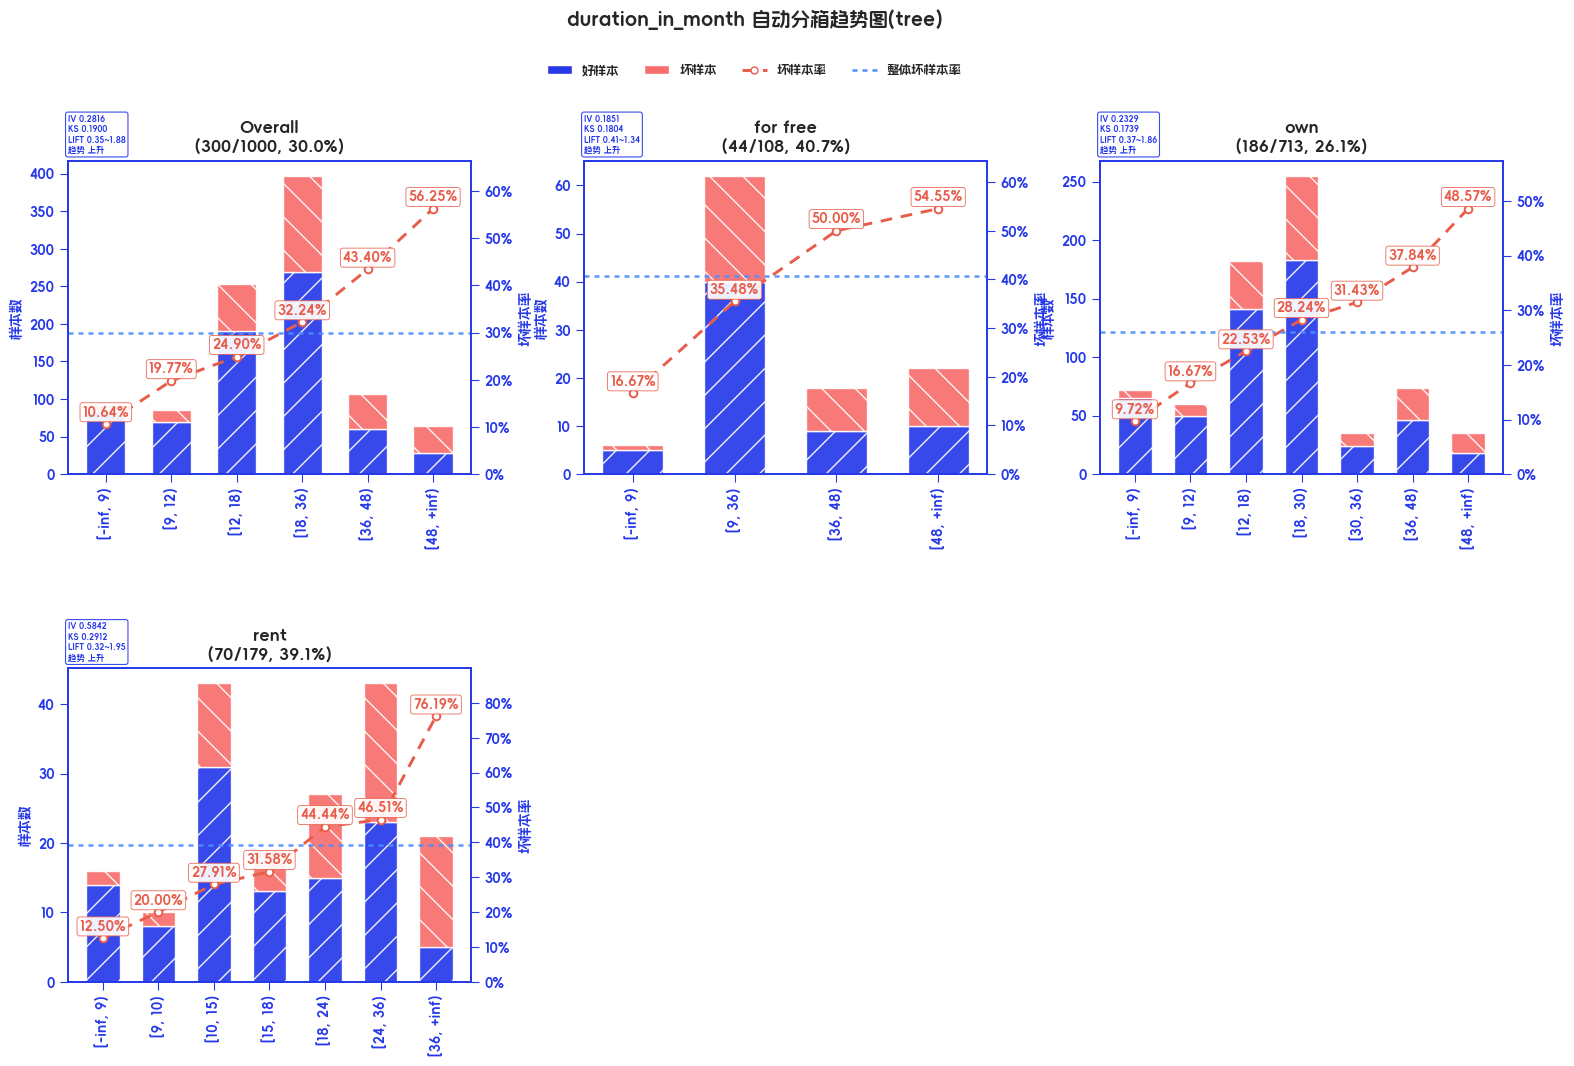

In [7]:
overdue_result = feature_efficiency_analysis(
    data=df,
    feature='duration_in_month',
    manual_rules=[12, 24, 36],
    overdue='MOB1',
    dpd=3,
    auto_method='tree',
    group_cols='housing',
    desc='duration_in_month'
)

print('实际目标列:', overdue_result['target'])
print('自动分箱规则:', overdue_result['auto_rules'])
display(overdue_result['manual_table'])
display(overdue_result['auto_table'])

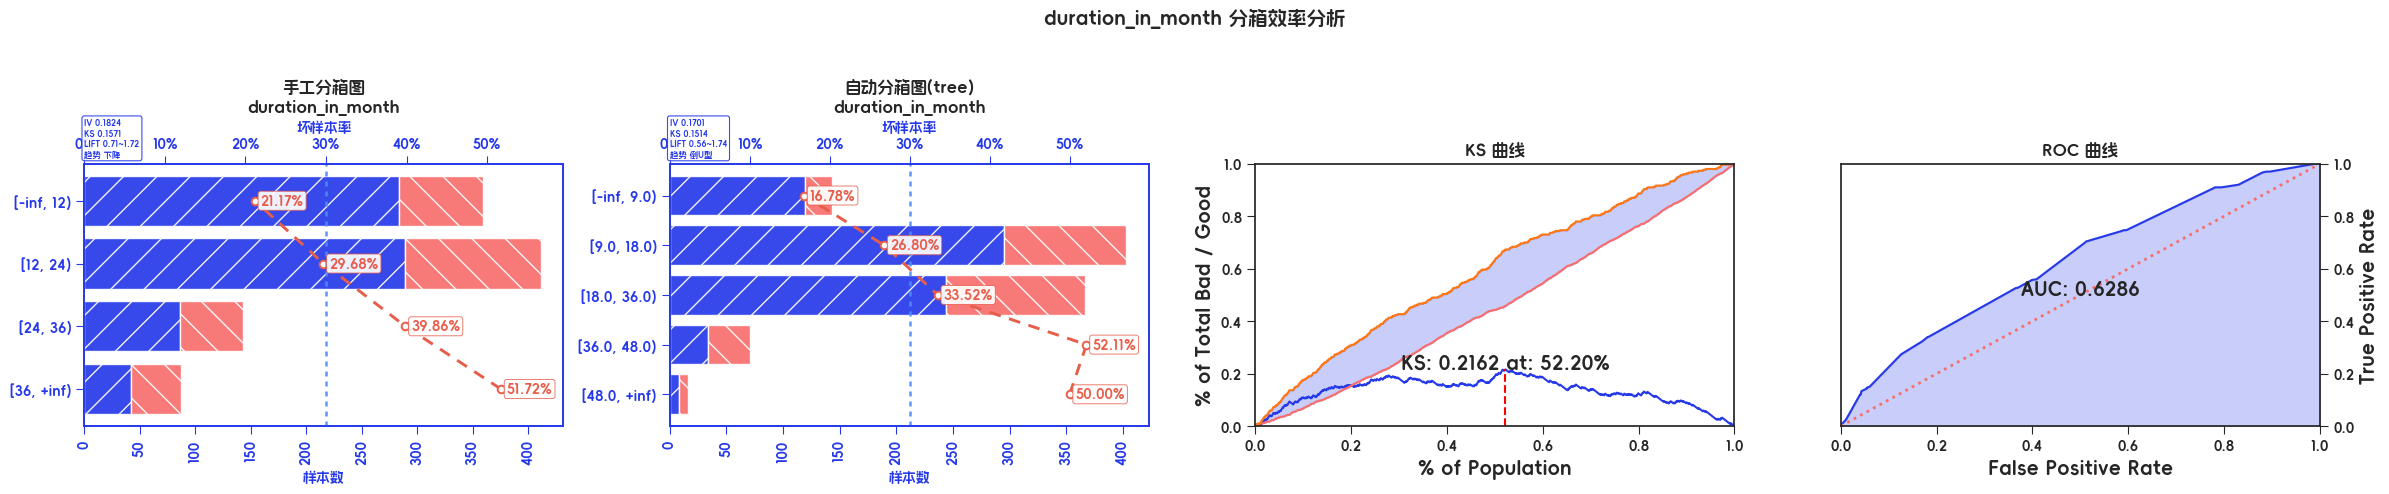

In [8]:
overdue_result['comparison_figure']